# Verify RobomimicWrapper (Evaluation Env)

Smoke test for `envs/robomimic_wrapper.py`. Checks:
1. Shapes and dtypes of images, proprio, view_present
2. Visual inspection of camera images (slots 0 and 3 should have real images, 1-2 zeroed)
3. Proprio values are reasonable
4. Step with random actions works
5. Short rollout with the evaluation loop

In [4]:
import sys
sys.path.insert(0, "c:/Users/naqee/OneDrive/Desktop/CSC415 Project/RAEDiTRobotics")

import numpy as np
import matplotlib.pyplot as plt
from data_pipeline.envs.robomimic_wrapper import RobomimicWrapper

env = RobomimicWrapper("lift")
obs = env.reset()
print(f"proprio_dim: {env.proprio_dim}")
print(f"num_cameras: {env.num_cameras}")


[robosuite INFO] Loading controller configuration from: c:\Users\naqee\OneDrive\Desktop\CSC415 Project\.venv\Lib\site-packages\robosuite\controllers\config\default\composite\basic.json (composite_controller_factory.py:121)
[robosuite WARNING] The config has defined for the controller "left", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for left from self.part_controller_config. (robot.py:151)
[robosuite WARNING] The config has defined for the controller "torso", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for torso from self.part_controller_config. (robot.py:151)
[robosuite WARNING] The config has defined for the controller "head", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for head from self.part_controller_config. (robot.py:151)
[robosuite WARNING] The config has defined 

proprio_dim: 9
num_cameras: 4


In [5]:
imgs = env.get_multiview_images()
proprio = env.get_proprio()
vp = env.get_view_present()

print(f"Images:  shape={imgs.shape}, dtype={imgs.dtype}")
print(f"Proprio: shape={proprio.shape}, dtype={proprio.dtype}")
print(f"View present: {vp}")
print(f"\nSlot 0 (agentview) has data: {np.any(imgs[0, 0] != 0)}")
print(f"Slot 1 (empty) all zeros:    {np.all(imgs[0, 1] == 0)}")
print(f"Slot 2 (empty) all zeros:    {np.all(imgs[0, 2] == 0)}")
print(f"Slot 3 (wrist) has data:     {np.any(imgs[0, 3] != 0)}")


Images:  shape=(1, 4, 3, 224, 224), dtype=float32
Proprio: shape=(1, 9), dtype=float32
View present: [ True False False  True]

Slot 0 (agentview) has data: True
Slot 1 (empty) all zeros:    True
Slot 2 (empty) all zeros:    True
Slot 3 (wrist) has data:     True


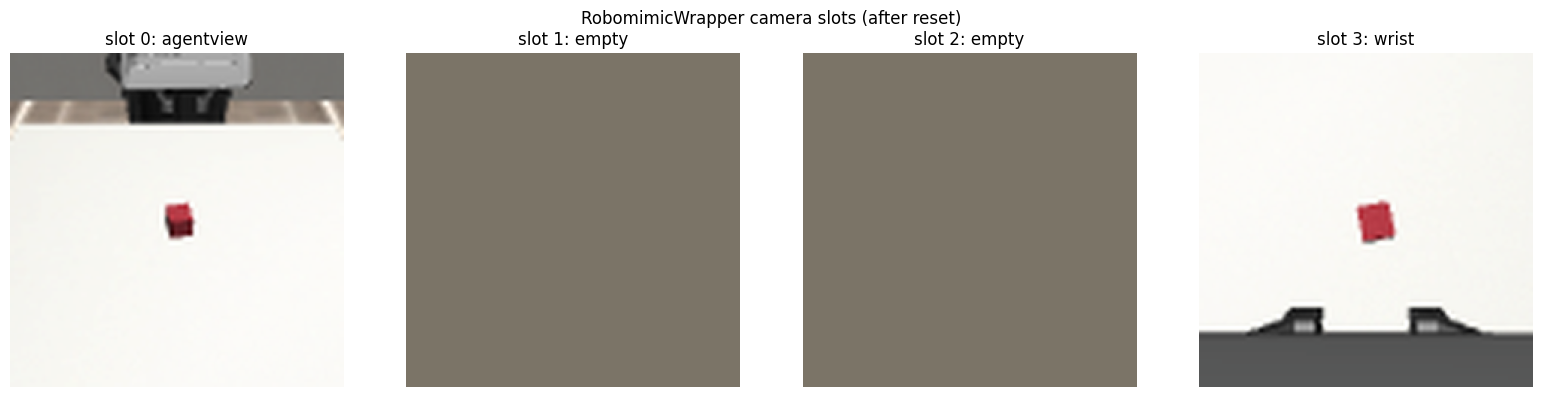

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
slot_names = ["slot 0: agentview", "slot 1: empty", "slot 2: empty", "slot 3: wrist"]
MEAN = np.array([0.485, 0.456, 0.406])
STD = np.array([0.229, 0.224, 0.225])

for i, (ax, name) in enumerate(zip(axes, slot_names)):
    img_chw = imgs[0, i]  # [3, H, W]
    img_hwc = np.moveaxis(img_chw, 0, -1)  # [H, W, 3]
    # Undo ImageNet normalization for display
    img_display = img_hwc * STD + MEAN
    img_display = np.clip(img_display, 0, 1)
    ax.imshow(img_display)
    ax.set_title(name)
    ax.axis("off")
plt.suptitle("RobomimicWrapper camera slots (after reset)")
plt.tight_layout()
plt.show()


In [7]:
print("Proprio breakdown:")
p = proprio[0]
print(f"  eef_pos (3):       {p[:3]}")
print(f"  eef_quat (4):      {p[3:7]}")
print(f"  gripper_qpos (2):  {p[7:9]}")
print(f"  quat norm:         {np.linalg.norm(p[3:7]):.6f} (should be ~1.0)")


Proprio breakdown:
  eef_pos (3):       [-0.09433137  0.01286223  1.0181899 ]
  eef_quat (4):      [ 0.99695385  0.01354222  0.07658784 -0.0058271 ]
  gripper_qpos (2):  [ 0.020833 -0.020833]
  quat norm:         1.000000 (should be ~1.0)


In [8]:
print("Stepping with 10 random actions...")
for i in range(10):
    action = np.random.uniform(-1, 1, size=7).astype(np.float32)
    obs, reward, done, info = env.step(action)
    print(f"  step {i+1}: reward={reward:.3f}, done={done}, success={info.get('success', False)}")

# Verify images update after stepping
imgs_after = env.get_multiview_images()
proprio_after = env.get_proprio()
print(f"\nImages changed after stepping: {not np.allclose(imgs, imgs_after)}")
print(f"Proprio changed after stepping: {not np.allclose(proprio, proprio_after)}")


Stepping with 10 random actions...
  step 1: reward=0.000, done=False, success=False
  step 2: reward=0.000, done=False, success=False
  step 3: reward=0.000, done=False, success=False
  step 4: reward=0.000, done=False, success=False
  step 5: reward=0.000, done=False, success=False
  step 6: reward=0.000, done=False, success=False
  step 7: reward=0.000, done=False, success=False
  step 8: reward=0.000, done=False, success=False
  step 9: reward=0.000, done=False, success=False
  step 10: reward=0.000, done=False, success=False

Images changed after stepping: True
Proprio changed after stepping: True


## Short rollout with evaluate_policy


In [9]:
import torch
from data_pipeline.evaluation.rollout import evaluate_policy

class RandomPolicy:
    def predict(self, images, proprio, view_present):
        return torch.randn(50, 7) * 0.1

env2 = RobomimicWrapper("lift")
sr, results = evaluate_policy(
    RandomPolicy(), env2,
    num_episodes=3, max_steps=50,
    exec_horizon=8, obs_horizon=2,
)
print(f"Random policy success rate: {sr:.2f} (expected ~0.0)")
for i, r in enumerate(results):
    print(f"  Episode {i}: steps={r['steps']}, success={r['success']}")
env2.close()
env.close()
print("\nAll checks passed!")


[robosuite INFO] Loading controller configuration from: c:\Users\naqee\OneDrive\Desktop\CSC415 Project\.venv\Lib\site-packages\robosuite\controllers\config\default\composite\basic.json (composite_controller_factory.py:121)
[robosuite WARNING] The config has defined for the controller "left", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for left from self.part_controller_config. (robot.py:151)
[robosuite WARNING] The config has defined for the controller "torso", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for torso from self.part_controller_config. (robot.py:151)
[robosuite WARNING] The config has defined for the controller "head", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for head from self.part_controller_config. (robot.py:151)
[robosuite WARNING] The config has defined 

Random policy success rate: 0.00 (expected ~0.0)
  Episode 0: steps=50, success=False
  Episode 1: steps=50, success=False
  Episode 2: steps=50, success=False

All checks passed!
